In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('spotify_tracks.csv')

print(df.shape)
print(df.head())
print(df.info())
print(df['track_genre'].value_counts())

(114000, 21)
   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826 

In [2]:
popular_genres = ['pop', 'rock', 'hip-hop', 'country', 'r-n-b', 'jazz', 
                  'classical', 'electronic', 'indie', 'metal', 'folk', 
                  'blues', 'reggae', 'alternative', 'dance']

df_filtered = df[df['track_genre'].isin(popular_genres)].copy()

print(f"Filtered: {len(df_filtered)} songs")
print(df_filtered['track_genre'].value_counts())

Filtered: 15000 songs
track_genre
alternative    1000
blues          1000
classical      1000
country        1000
dance          1000
electronic     1000
folk           1000
hip-hop        1000
indie          1000
jazz           1000
metal          1000
pop            1000
r-n-b          1000
reggae         1000
rock           1000
Name: count, dtype: int64


In [3]:
X = df_filtered.drop('track_genre', axis=1)
y = df_filtered['track_genre']

# Drop non-numeric columns
X = X.drop(['artists', 'album_name', 'track_name', 'track_id', 'Unnamed: 0'], axis=1, errors='ignore')

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")

Features: (15000, 15)
Target: (15000,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (12000, 15), Test: (3000, 15)


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("Label encoding done!")

Label encoding done!


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

pipeline_xgb = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0))
])

print("Training XGBoost...")
pipeline_xgb.fit(X_train, y_train_encoded)
xgb_score = pipeline_xgb.score(X_test, y_test_encoded)
print(f"XGBoost Accuracy: {xgb_score:.4f}")

Training XGBoost...
XGBoost Accuracy: 0.5233


In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [5, 10, 15],
    'classifier__learning_rate': [0.01, 0.1, 0.2]
}

print("Tuning XGBoost... (this takes time)")
grid_search = GridSearchCV(pipeline_xgb, param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train_encoded)

print(f"\nBest params: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")
test_accuracy = grid_search.score(X_test, y_test_encoded)
print(f"Test Accuracy: {test_accuracy:.4f}")

Tuning XGBoost... (this takes time)
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best params: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 15, 'classifier__n_estimators': 150}
Best CV Score: 0.5229
Test Accuracy: 0.5213


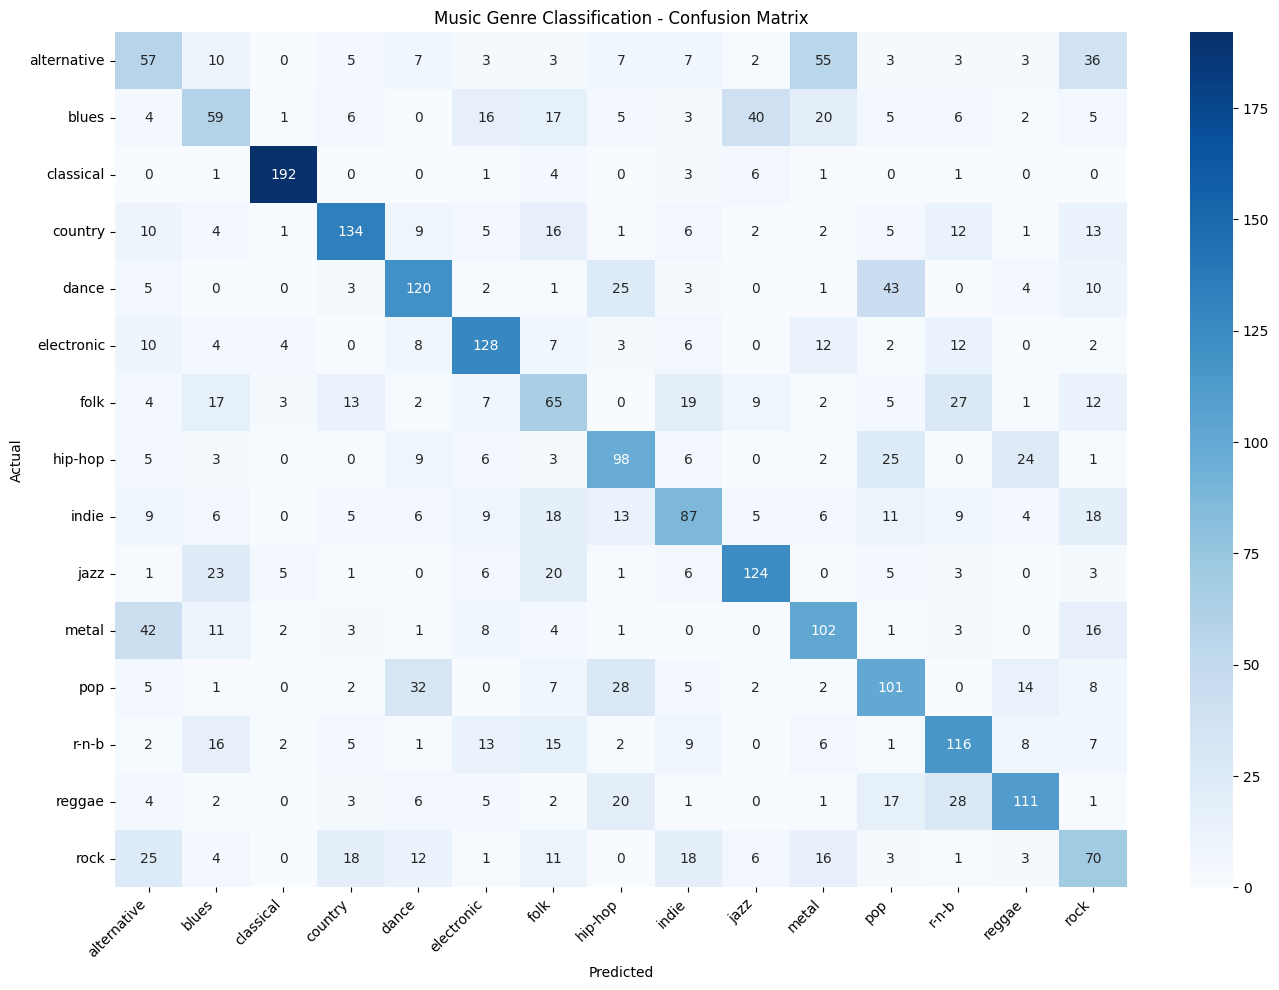

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = grid_search.predict(X_test)

y_pred_genres = le.inverse_transform(y_pred)
y_test_genres = le.inverse_transform(y_test_encoded)

cm = confusion_matrix(y_test_genres, y_pred_genres, labels=le.classes_)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Music Genre Classification - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
import pickle

with open('genre_classifier.pkl', 'wb') as f:
    pickle.dump(grid_search, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Model and encoder saved!")

Model and encoder saved!
